# Prueba Técnica: Sistema Híbrido de Recomendación y Personalización de Retail (GenAI + ML)

### Tarea 1: Extracción y Procesamiento de Datos (SQL y Python)

#### Tablas y variables de base de datos relacional: 
- **clientes**: id_cliente, nombre
- **transacciones**: id_transaccion, id_cliente, id_producto, fecha
- **producto**: id_producto, precio, categoría

#### Supuestos
- En una transacción se pueden adquirir múltiples productos por lo que cada fila de **transacciones** representa un producto dentro de una transacción. Por ende, múltiples filas pueden tener el mismo **id_transaccion**.

#### 1. Consulta SQL 

SELECT  
&emsp; t.id_cliente,   
&emsp; COUNT(DISTINCT t.id_transaccion) AS frecuencia, -- cuenta el número de transacciones por cliente   
&emsp; SUM(p.precio) AS monto_total_gastado, -- suma los montos individuales por cliente  
&emsp; DATEDIFF(CURDATE(), MAX(t.fecha)) AS recencia -- calcula los dias entre la ultima transaccion y el día actual  
FROM transacciones AS t  
JOIN productos AS p ON t.id_producto = p.id_producto  
GROUP BY t.id_cliente

#### 2. Dataset sintético para 1000 clientes

In [25]:
import numpy as np 
import pandas as pd

np.random.seed(220516)

# Cantidad de clientes, posibles categorías favoritas, frecuencia
clientes = 1000
categorias = ["Construcción", "Acabados", "Cocina", "Herramientas", "Pintura"]
nombres = ["Ana", "Boris", "Carla", "Diego", "Elena", "Fernando", "Gabriela", "Héctor", "Isabel", "Jorge"]

# Crear dataset sintético 
df = pd.DataFrame({
    "id_cliente": np.arange(1, clientes + 1),
    "nombre": np.random.choice(nombres, clientes),
    "frecuencia": 1+ np.random.poisson(3, clientes),
    "monto_total_gastado": 10 + np.round(np.random.exponential(100, clientes), 2), # Compra mínima de $10
    "recencia": np.random.randint(1, 366, clientes), # Asume clientes transacciones en el último año
    "categoria_fav": np.random.choice(categorias, clientes)}) 

df.head()

,id_cliente,nombre,frecuencia,monto_total_gastado,recencia,categoria_fav
0,1,Boris,4,114.99,340,Construcción
1,2,Isabel,6,156.16,345,Herramientas
2,3,Carla,3,103.77,175,Herramientas
3,4,Elena,6,15.87,21,Herramientas
4,5,Diego,2,264.71,335,Construcción


### Tarea 2: Modelo Predictivo (Machine Learning Tradicional)

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

X = df[["frecuencia", "monto_total_gastado", "recencia"]].values

# Normalizar las variables para que estén en la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar el GMM con distintos números de clusters (1 a 10)
bic = []
log_likelihoods = []
k_values = range(1, 11) 

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=220516)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))

    # log-likelihood promedio por cliente * número de clientes
    log_likelihoods.append(gmm.score(X_scaled) * len(X_scaled))

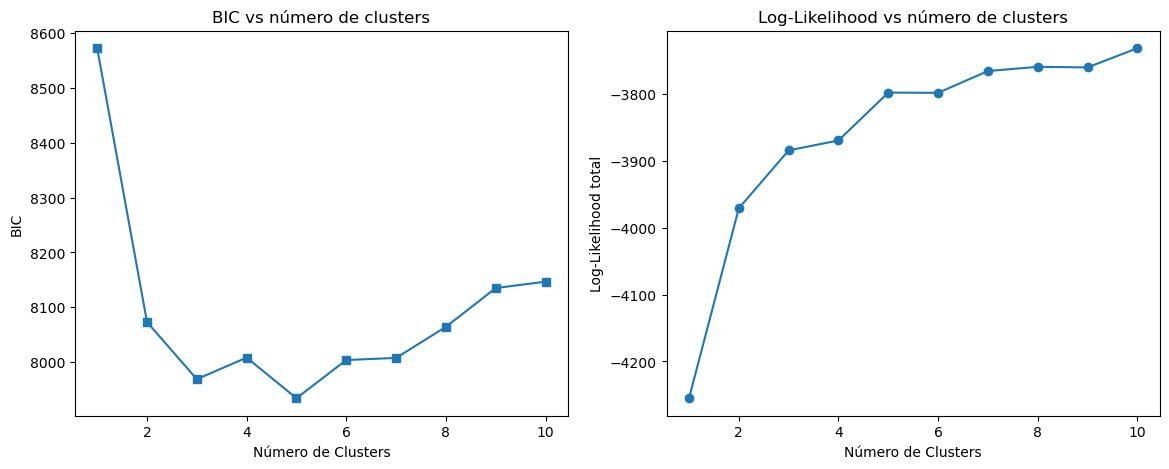

In [27]:
# Graficar BIC y log-likelihood para identificar el número óptimo de clusters
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graficar BIC
ax[0].plot(k_values, bic, marker='s')
ax[0].set_xlabel("Número de Clusters")
ax[0].set_ylabel("BIC")
ax[0].set_title("BIC vs número de clusters")

# Graficar log-likelihood total
ax[1].plot(k_values, log_likelihoods, marker="o")
ax[1].set_xlabel("Número de Clusters")
ax[1].set_ylabel("Log-Likelihood total")
ax[1].set_title("Log-Likelihood vs número de clusters")

plt.show()

In [28]:
from sklearn.metrics import silhouette_score

# Número óptimo de clusters minimizando BIC
k = k_values[np.argmin(bic)]

# Modelo con número optimo de clusters
gmm = GaussianMixture(n_components=k, random_state=220516)
gmm.fit(X_scaled)

# Asignar el cluster y probabilidad a cada cliente
df["cluster"] = gmm.predict(X_scaled)
df["prob_cluster"] = gmm.predict_proba(X_scaled).max(axis=1)

#Promedio por cluster
df.groupby("cluster")[["frecuencia", "monto_total_gastado", "recencia", "prob_cluster"]].mean().round(2)

,frecuencia,monto_total_gastado,recencia,prob_cluster
cluster,,,,
0,4.02,275.99,195.60,0.88
1,3.26,86.28,55.74,0.76
2,5.84,111.83,216.62,0.65
3,3.18,86.85,265.72,0.71
4,4.07,30.81,206.96,0.74


In [29]:
#Desviación estándar por cluster
df.groupby("cluster")[["frecuencia", "monto_total_gastado", "recencia", "prob_cluster"]].std().round(2) 

,frecuencia,monto_total_gastado,recencia,prob_cluster
cluster,,,,
0,1.52,96.05,95.24,0.18
1,1.22,47.72,35.44,0.17
2,2.00,37.05,93.87,0.19
3,1.22,25.56,58.49,0.15
4,1.78,12.16,92.20,0.14


In [30]:
# Porcentaje de clientes por cluster
df["cluster"].value_counts() / 1000 * 100

cluster
4    29.2
1    22.0
0    20.3
3    18.3
2    10.2
Name: count, dtype: float64

In [31]:
# Calcular el silhouette score 
silhouette = silhouette_score(X_scaled, df["cluster"])
print("Silhouette Score:", f"{silhouette:.2f}")

Silhouette Score: 0.12


### Explicación de elección de modelo

Elegí un Gaussian Mixture Model para este análisis por 3 principales motivos. 

Primero, el GMM realiza **asignaciones probabilísticas** (soft clustering), es decir, calcula la probabilidad de que el cliente pertenezca a cada uno de los clusters. Esto es importante ya que puede superposición entre los grupos (indicado por el silhouette score), por lo que los grupos no son completamente separables

Segundo, el GMM es más flexible y **modela formas, tamaños y covarianzas distintas por cluster**. Esto lo adpata mejor a la data de clientes donde no todos se comportan de la misma manera. 

Por último, el modelo permite su evaluación a través de BIC, lo cual permite obtener un modelo que **balancea el fit con complejidad**. Esto permite evitar "overfitting" y elegir el número óptimo de clusters, facilitando la interpretación de resultados. 

#### Interpretación de resultados

El modelo indica un número óptimo de 4 en los que calificar los clientes que pueden interpretarse de la siguiente manera:

**Clientes de alto valor (n=329)** - Cluster 0

- Son el grupo de clientes que más gasta con diferencia y visita las sucursales con frecuencia. Sin embargo, hace mucho tiempo no realizan una compra lo que lo convierte en un grupo en alto riesgo de fuga y de prioridad debido a su nivel alto de gasto y volumen.

**Clientes de bajo valor (n=319)** - Cluster 1

- Son el grupo de clientes qe con el menor gasto promedio y con menor frecuencia de compra, lo que indica clientes más ocacionales. Además, tienen la segunda recencia más elevada. Probablemente, debido a lo anterior, son el grupo menos prioritario aún estando en riego de fuga.

**Clientes estándar (n=219)** - Cluster 2

- Son el grupo de clientes más activo y más leales a la empresa. Compran con frecuencia y han comprado más recientemente aunque su gasto promedio no es tan elevado. Son un grupo que no esta en riesgo de fuga pero debe prioriatio en términos de mantenerlos activos. 

**Clientes inactivos (n=133)** - Cluster 3

- Son el grupo de clientes que fue históricamente muy bueno en terminos de frecuencia y gasto. Sin embargo, su última compra se realizo hace más de 8 meses en promedio. Son clientes en el mayor riesgo de fuga debido a su inactividad reciente. 

### Tarea 3: Personalización Generativa (Gen AI)

In [32]:
# Crear variable con nombre de clusters
df["nombre_cluster"] = df["cluster"].apply(lambda x: "Alto valor" if x == 0
                                     else "Bajo valor" if x == 1 
                                     else "Estandar" if x == 2
                                     else "Inactivo")

df.head()

,id_cliente,nombre,frecuencia,monto_total_gastado,recencia,categoria_fav,cluster,prob_cluster,nombre_cluster
0,1,Boris,4,114.99,340,Construcción,3,0.644211,Inactivo
1,2,Isabel,6,156.16,345,Herramientas,2,0.760475,Estandar
2,3,Carla,3,103.77,175,Herramientas,3,0.604851,Inactivo
3,4,Elena,6,15.87,21,Herramientas,4,0.636969,Inactivo
4,5,Diego,2,264.71,335,Construcción,0,0.977054,Alto valor


In [33]:
# pip install openai python-dotenv

In [34]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI

# Cargar variable de entorno con la OpenAI API key
load_dotenv()

# Inicializar el cliente de OpenAI 
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Flag para utilizar mock en lugar de créditos reales
MOCK = True

#Función de mensaje de notificación psuh
def notificacion_push(cliente):
    
    # Extraer información del cliente
    nombre = cliente["nombre"].values[0]
    cluster = cliente["nombre_cluster"].values[0]
    monto_total_gastado = cliente["monto_total_gastado"].values[0]
    categoria = cliente["categoria_fav"].values[0]

    prompt = f""" Eres un experto en e-commerce y marketing enfocado en generar notificaciones push personalizadas para clientes de una Cochez, una compañía de líder en materiales de construcción, acabados y ferretería. 

Los clientes de la compañia han sido segmentados en 4 clusters: 

- Clientes de alto valor: promueve productos premium y busca reactivarlos.
- Clientes de bajo valor: promueve productos nuevos y/o de bajo costo 
- Clientes estándar: agradece y promueve su lealtad, promueve productos nuevos.
- Clientes inactivos: invitalos a volver con mensajes sobre oportunidades y proyectos.

Además, conocemos información del cliente como:

- Nombre
- Monto total gastado
- Cluster
- Categoría más comprada

Utiliza el monto total gastado para adaptar el tono del mensaje:
- Clientes con monto total gastado alto deben recibir mensajes más exclusivos y sobre productos premium.
- Clientes con monto total gastado bajo deben recibir mensajes enfocados en productos nuevos y de bajo costo.

Sugiere un descuento según el valor del cliente.

Utiliza la categoría más comprada para personalizar el mensaje.

Ejemplo 1: 

Cliente:
- Nombre: Ana
- Monto total gastado: 300
- Cluster: Alto Valor
- Categoría más comprada: Cocina

Respuesta: {{ "asunto": "Ana, pásate por Cochez",
              "cuerpo de mensaje": "Tenemos los mejores productos de cocina esperando por ti",
              "cupon_descuento_sugerido": "Haz click aquí para 10% de descuento en tu próxima compra"}}

Ejemplo 2: 

Cliente:
- Nombre: Boris
- Monto total gastado: 15
- Cluster: Inactivo
- Categoría más comprada: Herramientas

Respuesta: {{ "asunto": "Te extrañamos",
              "cuerpo de mensaje": "Las mejores herramientas para tus proyectos las encuentras en Cochez", 
              "cupon_descuento_sugerido": "Haz click aquí para 25% de descuento en tu próxima compra"}}

Basandote en la información del cliente, genera una notificación para: 

Cliente
- Nombre: {nombre}
- Monto total gastado: {monto_total_gastado}
- Cluster: {cluster}
- Categoría más comprada: {categoria}

Devuelve únicamente un objeto JSON válido que contenga un asunto y un cuerpo de mensaje para la notificación.
La estructura del JSON debe ser exactamente:

{{
  "asunto": "...",
  "cuerpo_mensaje": "...",
  "cupon_descuento_sugerido": "..." 
}}

No incluyas explicaciones, comentarios, ni texto adicional.
"""
    
    # Respuesta de mock
    if MOCK:
        
        notificacion = {
            "asunto": f"{nombre}, tenemos ofertas para ti",
            "cuerpo_mensaje": f"Descubre los mejores productos de {categoria} en Cochez",
            "cupon_descuento_sugerido": "Haz click aquí para un 25% de descuento en tu próxima compra"
        }
        return notificacion

    # Respuesta de API
    respuesta = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"}
    )

    notificacion = respuesta.choices[0].message.content

    return json.loads(notificacion)

In [35]:
notificacion_push(df[df["id_cliente"] == 1])

{'asunto': 'Boris, tenemos ofertas para ti',
 'cuerpo_mensaje': 'Descubre los mejores productos de Construcción en Cochez',
 'cupon_descuento_sugerido': 'Haz click aquí para un 25% de descuento en tu próxima compra'}